# Battery storage arbitrage as a linear programme

A 50 MW / 100 MWh battery buys energy when the day-ahead price is low and sells when it is high.
The schedule is an LP with one twist: the state of charge links the hours together.

**What's in here**
- Variables `charge`, `discharge`, `soc` per hour; energy balance with efficiency; cyclic state of charge
- Maximising with `linprog` (negate), degradation cost, why LPs like charging and discharging simultaneously
- 730 daily LPs: perfect-foresight revenue vs a heuristic vs scheduling on a naive price forecast
- Revenue by month and year (regime dependence), sensitivity to efficiency and duration
- The same problem with a binary mode variable in `scipy.optimize.milp`

In [1]:
import numpy as np
import pandas as pd
from scipy.optimize import linprog, milp, LinearConstraint, Bounds, minimize
import matplotlib.pyplot as plt
%matplotlib inline

pd.set_option("display.width", 120)
pd.set_option("display.max_columns", 30)
np.set_printoptions(precision=4, suppress=True)

df = pd.read_csv("../data/hourly_power_clean.csv", parse_dates=["time"]).set_index("time")
df.head(3)

,consumption_mwh,temp_c,wind_ms,solar_wm2,price_eur_mwh
time,,,,,
2022-01-01 00:00:00+00:00,26858.4,0.11,7.00,0.0,81.83
2022-01-01 01:00:00+00:00,26177.8,-0.18,6.61,0.0,88.21
2022-01-01 02:00:00+00:00,26229.4,-1.11,7.14,0.0,84.71


## Battery parameters and units

Hourly steps, so a power limit of 50 MW means at most 50 MWh moved in an hour. Round-trip efficiency 0.85 is
split symmetrically: `eta_c = eta_d = sqrt(0.85)`. Energy is lost on the way *in* (`eta_c * charge` reaches the
cells) and on the way *out* (you must draw `discharge / eta_d` from the cells to deliver `discharge` to the grid).

**Pitfall:** at half-hourly settlement (the GB norm) a 50 MW limit is 25 MWh per period. Write the balance with an
explicit `dt` so that changing the resolution does not silently double the battery.

In [2]:
P_MAX = 50.0        # MW
E_MAX = 100.0       # MWh  (2-hour battery)
ETA = np.sqrt(0.85) # one-way efficiency, round trip 0.85
DEG = 2.0           # EUR per MWh of throughput (degradation / variable O&M)
dt = 1.0            # hours per step

def build_battery_lp(price, p_max=P_MAX, e_max=E_MAX, eta=ETA, deg=DEG, dt=dt, cyclic=True, soc0=None):
    """x = [charge(H), discharge(H), soc(H)]. Minimise cost = -(revenue) + degradation."""
    H = len(price)
    ch, dis, soc = slice(0, H), slice(H, 2 * H), slice(2 * H, 3 * H)
    c = np.zeros(3 * H)
    c[ch] = price * dt + deg * dt          # paying the price to charge, plus wear
    c[dis] = -price * dt + deg * dt        # earning the price to discharge, minus wear
    # soc_h - soc_{h-1} - eta*dt*ch_h + dt/eta*dis_h = 0
    A_eq = np.zeros((H, 3 * H)); b_eq = np.zeros(H)
    for h in range(H):
        A_eq[h, 2 * H + h] = 1
        A_eq[h, h] = -eta * dt
        A_eq[h, H + h] = dt / eta
        if h > 0:
            A_eq[h, 2 * H + h - 1] = -1
        elif cyclic:
            A_eq[h, 3 * H - 1] = -1          # soc_{-1} := soc_{H-1}
        else:
            b_eq[h] = soc0
    bounds = [(0, p_max)] * H + [(0, p_max)] * H + [(0, e_max)] * H
    return c, A_eq, b_eq, bounds

def solve_battery(price, **kw):
    c, A_eq, b_eq, bounds = build_battery_lp(price, **kw)
    res = linprog(c, A_eq=A_eq, b_eq=b_eq, bounds=bounds, method="highs")
    if res.status != 0:
        raise RuntimeError(res.message)
    H = len(price)
    out = pd.DataFrame({"price": price, "charge": res.x[:H], "discharge": res.x[H:2 * H], "soc": res.x[2 * H:]})
    out["revenue"] = (out["discharge"] - out["charge"]) * price * dt
    return out, res

## One day

Pick a day with a strong evening peak. The result should read like a story: charge in the small hours,
discharge at the peak, state of charge never outside [0, 100].

In [3]:
day = "2023-02-01"
price = df.loc[day, "price_eur_mwh"].to_numpy()
sched, res = solve_battery(price)
print("status", res.status, " revenue EUR %.0f  degradation EUR %.0f  net %.0f" %
      (sched["revenue"].sum(), DEG * (sched["charge"] + sched["discharge"]).sum(), -res.fun))
assert (sched["soc"] >= -1e-6).all() and (sched["soc"] <= E_MAX + 1e-6).all()
sched.round(1).iloc[[1, 2, 3, 4, 8, 16, 17, 18, 19, 23]]

status 0  revenue EUR 7436  degradation EUR 619  net 6817


,price,charge,discharge,soc,revenue
1,82.6,50.0,0.0,53.9,-4127.5
2,72.8,50.0,0.0,100.0,-3642.5
3,93.4,-0.0,0.0,100.0,0.0
4,121.4,0.0,-0.0,100.0,-0.0
8,136.0,0.0,0.0,45.8,0.0
16,130.3,0.0,0.0,100.0,0.0
17,157.6,0.0,42.2,54.2,6650.8
18,169.3,0.0,50.0,-0.0,8464.0
19,147.2,0.0,0.0,-0.0,0.0
23,132.8,0.0,0.0,0.0,0.0


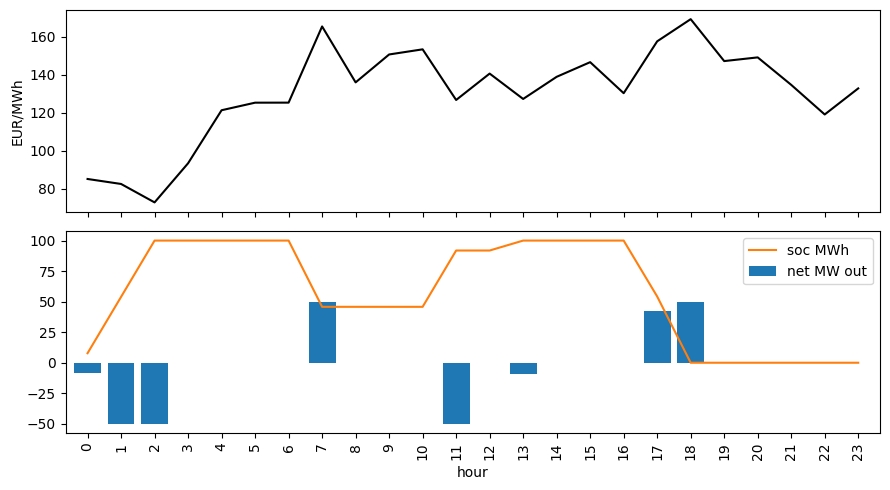

In [4]:
fig, ax = plt.subplots(2, 1, figsize=(9, 5), sharex=True)
sched["price"].plot(ax=ax[0], color="k"); ax[0].set_ylabel("EUR/MWh")
(sched["discharge"] - sched["charge"]).plot.bar(ax=ax[1], color="tab:blue", width=0.8, label="net MW out")
ax[1].plot(sched["soc"].values, color="tab:orange", label="soc MWh"); ax[1].legend(); ax[1].set_xlabel("hour")
plt.tight_layout(); plt.show()

## Simultaneous charge and discharge

Nothing in the LP forbids charging and discharging in the same hour. It only ever happens when it *pays*:
with a negative price and zero degradation cost the battery is paid to charge and can burn energy through
round-trip losses at the same time. A throughput cost removes it only once it exceeds the profit from burning
energy (here about 5 EUR/MWh, from the −30 price and 15% losses); a binary variable removes it for sure
(see the MILP section).

**Interview check:** "your schedule shows 50 MW charging and 50 MW discharging at 03:00 — is that a bug?"
Not a solver bug: a modelling gap. Say what constraint is missing and what it costs to add.

In [5]:
neg_price = price.copy(); neg_price[2:5] = -30.0            # force a negative-price window
both = lambda s: int(((s["charge"] > 1e-6) & (s["discharge"] > 1e-6)).sum())
for deg in [0.0, 2.0, 6.0]:
    s_deg, _ = solve_battery(neg_price, deg=deg)
    print("degradation %.0f EUR/MWh -> hours with simultaneous charge & discharge: %d" % (deg, both(s_deg)))
s_free, _ = solve_battery(neg_price, deg=0.0)
s_free.round(1).iloc[2:5]

degradation 0 EUR/MWh -> hours with simultaneous charge & discharge: 1
degradation 2 EUR/MWh -> hours with simultaneous charge & discharge: 1
degradation 6 EUR/MWh -> hours with simultaneous charge & discharge: 0


,price,charge,discharge,soc,revenue
2,-30.0,50.0,0.0,46.1,1500.0
3,-30.0,50.0,35.3,53.9,440.9
4,-30.0,50.0,0.0,100.0,1500.0


## Cyclic vs fixed start/end state of charge

A daily LP with a free end state sells everything in the last hour because leftover energy has no value inside
the model. Either make it cyclic (`soc_0 = soc_24`) or fix the end state or give leftover energy a value.

In [6]:
s_cyc, r_cyc = solve_battery(price, cyclic=True)
s_fix, r_fix = solve_battery(price, cyclic=False, soc0=50.0)
c, A_eq, b_eq, bounds = build_battery_lp(price, cyclic=False, soc0=50.0)   # free end: nothing pins soc_23
print("cyclic: net %.0f, soc end %.1f" % (-r_cyc.fun, s_cyc["soc"].iloc[-1]))
print("fixed start 50, free end: net %.0f, soc end %.1f  <- dumped" % (-r_fix.fun, s_fix["soc"].iloc[-1]))

cyclic: net 6817, soc end 0.0
fixed start 50, free end: net 11424, soc end 0.0  <- dumped


## All 730 days: perfect foresight, a heuristic, and a forecast

- **Perfect foresight**: the LP on actual prices, the upper bound on what the battery could ever earn.
- **Heuristic**: charge at full power in the two cheapest hours, discharge in the two dearest, then simulate the
  state of charge sequentially, clipping anything infeasible (e.g. trying to discharge before you charged).
- **Forecast**: schedule with *yesterday's* prices (a naive forecast), execute against today's actual prices.
  The schedule is always feasible (it only depends on the battery), but revenue depends on real prices.

The gap between perfect foresight and forecast-based revenue is the value of a better price forecast, which
is the number that decides whether a forecasting project is worth doing.

In [7]:
prices = df["price_eur_mwh"]
days = prices.resample("D").size()
days = days[days == 24].index                       # complete days only
P = np.stack([prices.loc[str(d.date())].to_numpy() for d in days])   # (n_days, 24)
print(P.shape)

def simulate(price, charge_plan, discharge_plan, e_max=E_MAX, eta=ETA, soc=0.0):
    """Execute a plan sequentially, clipping to what the state of charge allows."""
    rev = 0.0
    for h in range(len(price)):
        c = min(charge_plan[h], (e_max - soc) / eta)
        d = min(discharge_plan[h], soc * eta)
        soc += eta * c - d / eta
        rev += (d - c) * price[h] - DEG * (c + d)
    return rev

def heuristic_plan(price, n=int(E_MAX / P_MAX)):
    order = np.argsort(price)
    ch, dis = np.zeros(24), np.zeros(24)
    ch[order[:n]] = P_MAX; dis[order[-n:]] = P_MAX
    return ch, dis

rows = []
for i, d in enumerate(days):
    p = P[i]
    s_pf, r_pf = solve_battery(p)
    pf = -r_pf.fun
    heur = simulate(p, *heuristic_plan(p))
    if i > 0:
        s_fc, _ = solve_battery(P[i - 1])                       # plan on yesterday's prices
        fc = ((s_fc["discharge"] - s_fc["charge"]) * p).sum() - DEG * (s_fc["charge"] + s_fc["discharge"]).sum()
    else:
        fc = np.nan
    rows.append((d, pf, heur, fc, p.max() - p.min()))
daily = pd.DataFrame(rows, columns=["day", "perfect", "heuristic", "forecast", "spread"]).set_index("day")
daily.describe().round(0)

(730, 24)


,perfect,heuristic,forecast,spread
count,730.0,730.0,729.0,730.0
mean,8369.0,5178.0,2370.0,102.0
std,2996.0,3514.0,2865.0,42.0
min,2029.0,-11348.0,-14471.0,40.0
25%,6388.0,4243.0,736.0,80.0
50%,7864.0,5620.0,2407.0,92.0
75%,9751.0,6778.0,4049.0,107.0
max,22821.0,18530.0,15931.0,325.0


In [8]:
tot = daily[["perfect", "heuristic", "forecast"]].sum()
print((tot / 1e6).round(2).rename("EUR m over 2 years"))
print("heuristic captures %.0f%% of perfect foresight; naive forecast captures %.0f%%" %
      (100 * tot["heuristic"] / tot["perfect"], 100 * tot["forecast"] / tot["perfect"]))
print("days where the forecast schedule lost money:", int((daily["forecast"] < 0).sum()))

perfect      6.11
heuristic    3.78
forecast     1.73
Name: EUR m over 2 years, dtype: float64
heuristic captures 62% of perfect foresight; naive forecast captures 28%
days where the forecast schedule lost money: 129


The heuristic is poor mainly because it ignores ordering (you cannot discharge before you charge) and
the second-cheapest hour is often adjacent to the dearest one. The forecast result is the number that
matters for a real desk: it is what you would actually have earned.

**Interview check:** "perfect foresight revenue is 3.5× the forecast revenue: what would you work on?"
The price *shape* forecast (which hours are cheap/expensive), not the level. Arbitrage revenue depends
on the intraday spread; the level is irrelevant to a battery.

## Revenue by month and year: regime dependence

Arbitrage revenue is proportional to the intraday **spread**, not the price level. In this data the 2022 gas
spike lifted the level but not the spread (the spread comes from residual load), so the battery earned *less*
in the "crisis" year than in 2023. Whichever direction it goes, check revenue by year before quoting an annual figure:
one regime can dominate a two-year backtest.

      perfect (EUR m)  forecast (EUR m)
day                                    
2022             2.86              0.73
2023             3.25              0.99
correlation daily revenue vs daily spread: 0.85


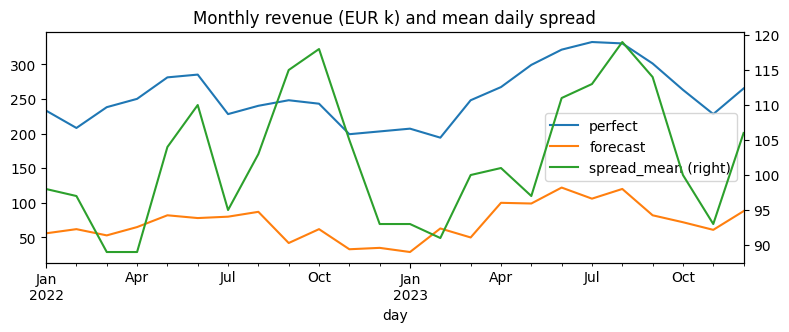

In [9]:
by_month = daily[["perfect", "forecast"]].resample("MS").sum() / 1e3
by_month["spread_mean"] = daily["spread"].resample("MS").mean()
by_year = daily[["perfect", "forecast"]].groupby(daily.index.year).sum() / 1e6
print(by_year.round(2).rename(columns=lambda c: c + " (EUR m)"))
print("correlation daily revenue vs daily spread: %.2f" % daily[["perfect", "spread"]].corr().iloc[0, 1])
by_month.round(0).plot(secondary_y="spread_mean", figsize=(9, 3), title="Monthly revenue (EUR k) and mean daily spread")
plt.show()

## Sensitivity: efficiency and duration

Same LP, different parameters, run on 2023 only to keep it quick. Duration is `E_MAX / P_MAX`: a 1-hour
battery can only exploit one cheap and one dear hour; a 4-hour battery exploits four but with the same power.

In [10]:
idx_2023 = np.array([d.year == 2023 for d in days])
P23 = P[idx_2023]
table = {}
for dur in [1, 2, 4]:
    for rt in [0.75, 0.85, 0.95]:
        eta = np.sqrt(rt)
        rev = sum(-solve_battery(p, e_max=P_MAX * dur, eta=eta)[1].fun for p in P23)
        table[(f"{dur}h", rt)] = rev / 1e6
sens = pd.Series(table).unstack()
sens.index.name = "duration"; sens.columns.name = "round-trip eff"
print("2023 perfect-foresight revenue, EUR m")
sens.round(2)

2023 perfect-foresight revenue, EUR m


round-trip eff,0.75,0.85,0.95
duration,,,
1h,1.65,2.12,2.74
2h,2.53,3.25,4.12
4h,3.54,4.62,5.82


Revenue per MWh of capacity *falls* with duration (the extra hours are less profitable), which is exactly
the question a capital-allocation desk asks: is the fourth hour of storage worth its cost?

**Extension, not implemented here:** real batteries stack revenues across day-ahead, intraday and balancing
markets and provide frequency response. Each adds a market with its own timing and uncertainty; the LP structure
is the same, the decision timeline is the hard part.

## The MILP version: a binary mode variable

Add `mode_h in {0, 1}`: `charge_h <= P_MAX * mode_h`, `discharge_h <= P_MAX * (1 - mode_h)`.
`scipy.optimize.milp` takes `LinearConstraint(A, lb, ub)` objects, `Bounds`, and an `integrality` vector.
Integer problems can be much slower than LPs; here it is 24 binaries and instant.

In [11]:
def solve_battery_milp(price, p_max=P_MAX, e_max=E_MAX, eta=ETA, deg=DEG):
    H = len(price)
    c, A_eq, b_eq, bounds = build_battery_lp(price, p_max, e_max, eta, deg)
    n = 4 * H                                    # + mode(H)
    c_m = np.concatenate([c, np.zeros(H)])
    A_eq_m = np.hstack([A_eq, np.zeros((H, H))])
    # charge_h - p_max*mode_h <= 0 ;  discharge_h + p_max*mode_h <= p_max
    A1 = np.hstack([np.eye(H), np.zeros((H, 2 * H)), -p_max * np.eye(H)])
    A2 = np.hstack([np.zeros((H, H)), np.eye(H), np.zeros((H, H)), p_max * np.eye(H)])
    cons = [LinearConstraint(A_eq_m, b_eq, b_eq),
            LinearConstraint(A1, -np.inf, 0),
            LinearConstraint(A2, -np.inf, p_max)]
    lb = np.array([b[0] for b in bounds] + [0] * H, dtype=float)
    ub = np.array([b[1] for b in bounds] + [1] * H, dtype=float)
    integrality = np.concatenate([np.zeros(3 * H), np.ones(H)])
    res = milp(c_m, constraints=cons, bounds=Bounds(lb, ub), integrality=integrality)
    return res

r_milp = solve_battery_milp(neg_price, deg=0.0)
print("status", r_milp.status, r_milp.message)
ch, dis = r_milp.x[:24], r_milp.x[24:48]
print("simultaneous hours:", int(((ch > 1e-6) & (dis > 1e-6)).sum()),
      " | LP net %.0f  MILP net %.0f" % (-solve_battery(neg_price, deg=0.0)[1].fun, -r_milp.fun))

status 0 Optimization terminated successfully. (HiGHS Status 7: Optimal)
simultaneous hours: 0  | LP net 19496  MILP net 19309


## Checklist

1. Write the energy balance with explicit `dt` and put the efficiency on the correct side of each flow.
2. Decide what happens at the boundary: cyclic, fixed end, or a value for leftover energy. Never leave it free.
3. `linprog` minimises: cost = −revenue + wear. Check the sign by hand on one hour.
4. Look for simultaneous charge/discharge; decide whether a throughput cost or a binary is the right fix.
5. Perfect foresight is an upper bound, not a forecast of earnings. Always report the forecast-based number.
6. Revenue scales with intraday spread; check regime dependence (2022 vs 2023) before quoting an annual figure.
7. Report sensitivity to efficiency and duration; the marginal hour of storage is what the capex decision hinges on.